# AdaFTRL-V2 Showcase

This notebook compares four methods on the same censored survival stream:

- ACI with IPCW
- ACI without IPCW
- original AdaFTRL
- `adaftrl_v2`, the ambiguity-neutral AdaFTRL update

The point of `adaftrl_v2` is to avoid treating every censored round as equally informative. If `Y >= L`, coverage is known because `T >= Y >= L`. The genuinely ambiguous case is `Delta = 0` and `Y < L`: censoring happened below the lower bound, so we do not know whether `T < L`. Original AdaFTRL uses IPCW error `0` there, which creates upward drift under heavy censoring. `adaftrl_v2` instead uses feedback value `alpha` on that ambiguous region, so the internal gradient is zero.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from online_survival.experiments import (
    SimulationConfig,
    behavior_svg,
    format_markdown_table,
    run_one_experiment,
    run_repeated_experiments,
    summarize_one_run,
    summarize_repeats,
)


def show_markdown(markdown):
    try:
        from IPython.display import Markdown, display
        display(Markdown(markdown))
    except Exception:
        print(markdown)


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg[:1000])

## Experiment Setup

The censoring rate is intentionally high. This creates many ambiguous censored-below-bound rounds, so the difference between original AdaFTRL and `adaftrl_v2` is visible.

In [2]:
config = SimulationConfig(
    n_rounds=1000,
    alpha=0.10,
    tau_max=0.50,
    eta=0.008,
    model_log_shift=0.30,
    censoring_rate=0.60,
)

config

SimulationConfig(n_rounds=1000, alpha=0.1, tau_max=0.5, eta=0.008, tau_min=1e-06, x_low=-1.0, x_high=1.0, true_intercept=1.0, true_slope=0.35, true_sigma=0.55, model_log_shift=0.3, model_sigma=0.55, censoring_rate=0.6)

## One Run Behavior

The table reports realized coverage, conditional coverage under the known synthetic law, and the fraction of rounds that were ambiguous for each algorithm's own lower bound.

| algorithm | realized_coverage | target_coverage | coverage_abs_error | average_conditional_coverage | average_surrogate_error | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8850 | 0.9000 | 0.0150 | 0.8789 | 0.1061 | 0.5420 | 0.0504 | 0.7660 |
| ACI without IPCW | 0.7670 | 0.9000 | 0.1330 | 0.7614 | 0.1020 | 0.6280 | 0.0832 | 0.7660 |
| AdaFTRL | 0.8630 | 0.9000 | 0.0370 | 0.8543 | 0.1182 | 0.5690 | 0.0511 | 0.7660 |
| AdaFTRL-V2 | 0.9140 | 0.9000 | 0.0140 | 0.9051 | 0.0871 | 0.5230 | 0.0219 | 0.7660 |

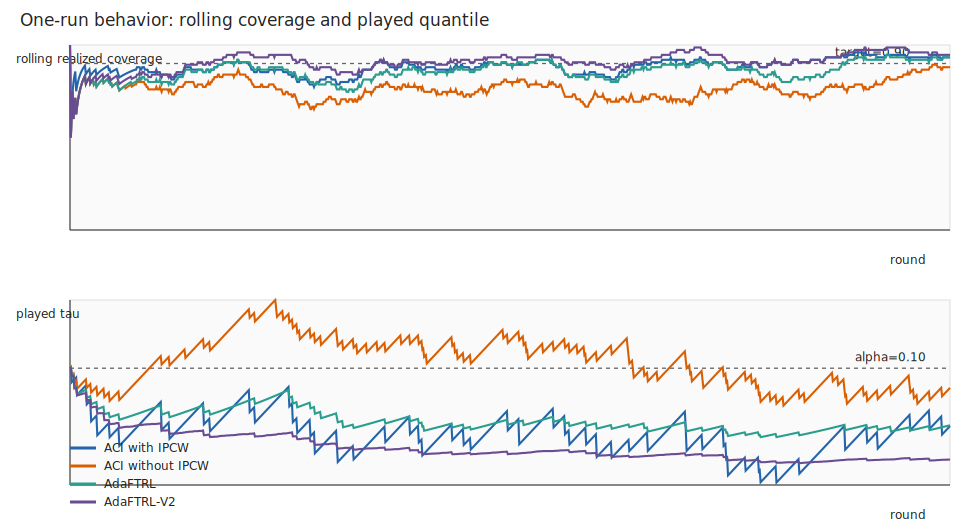

In [3]:
one_run = run_one_experiment(config, seed=17, include_adaftrl_v2=True)

one_run_columns = [
    "algorithm",
    "realized_coverage",
    "target_coverage",
    "coverage_abs_error",
    "average_conditional_coverage",
    "average_surrogate_error",
    "ambiguous_below_bound_fraction",
    "final_tau",
    "censoring_fraction",
]
show_markdown(format_markdown_table(summarize_one_run(one_run), one_run_columns, digits=4))
show_svg(behavior_svg(one_run, window=75))

## Repeated Experiments

`coverage_abs_error_mean` measures distance from the 0.90 target. In this condition, `adaftrl_v2` is better than original AdaFTRL because it has much smaller target error and smaller undercoverage shortfall.

In [4]:
repeated = run_repeated_experiments(
    config,
    n_repeats=100,
    seed=2026,
    include_adaftrl_v2=True,
)
summary = summarize_repeats(repeated)

summary_columns = [
    "algorithm",
    "realized_coverage_mean",
    "realized_coverage_se",
    "coverage_abs_error_mean",
    "coverage_shortfall_mean",
    "average_conditional_coverage_mean",
    "average_surrogate_error_mean",
    "ambiguous_below_bound_fraction_mean",
    "final_tau_mean",
    "censoring_fraction_mean",
]
show_markdown(format_markdown_table(summary, summary_columns, digits=4))

| algorithm | realized_coverage_mean | realized_coverage_se | coverage_abs_error_mean | coverage_shortfall_mean | average_conditional_coverage_mean | average_surrogate_error_mean | ambiguous_below_bound_fraction_mean | final_tau_mean | censoring_fraction_mean |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8922 | 0.0009 | 0.0091 | 0.0085 | 0.8924 | 0.1086 | 0.5454 | 0.0370 | 0.7748 |
| ACI without IPCW | 0.7778 | 0.0017 | 0.1222 | 0.1222 | 0.7775 | 0.1003 | 0.6316 | 0.0972 | 0.7748 |
| AdaFTRL | 0.8729 | 0.0009 | 0.0271 | 0.0271 | 0.8732 | 0.1280 | 0.5683 | 0.0372 | 0.7748 |
| AdaFTRL-V2 | 0.9092 | 0.0008 | 0.0104 | 0.0006 | 0.9097 | 0.0915 | 0.5310 | 0.0185 | 0.7748 |

## AdaFTRL vs AdaFTRL-V2 Only

This smaller table isolates the comparison requested in the manuscript update.

In [5]:
ada_only = [row for row in summary if row["algorithm"] in {"AdaFTRL", "AdaFTRL-V2"}]
ada_columns = [
    "algorithm",
    "realized_coverage_mean",
    "coverage_abs_error_mean",
    "coverage_shortfall_mean",
    "ambiguous_below_bound_fraction_mean",
    "final_tau_mean",
]
show_markdown(format_markdown_table(ada_only, ada_columns, digits=4))

| algorithm | realized_coverage_mean | coverage_abs_error_mean | coverage_shortfall_mean | ambiguous_below_bound_fraction_mean | final_tau_mean |
| --- | --- | --- | --- | --- | --- |
| AdaFTRL | 0.8729 | 0.0271 | 0.0271 | 0.5683 | 0.0372 |
| AdaFTRL-V2 | 0.9092 | 0.0104 | 0.0006 | 0.5310 | 0.0185 |